In [1]:
import lightkurve
import matplotlib.pyplot as plot
import numpy
%matplotlib inline
plot.style.use('seaborn-v0_8')

In [2]:
'''
How to not have a million false positives!
1) Make sure that there is no v-shaped transit by zooming in
2) Make sure no even-odd rule
3) Remove data with noise to see others clearer
4) Even slight 2nd transits, like 1 / 10 the size of the initial transit, are EBs.
5) Ask ChatGPT about the period, first transit size and 2nd transit size: it tells you if it is bad.
6) Always look at the unflattened / untouched curves, but flatten if the fold cannot be made.
7) ALWAYS ZOOM IN to be sure about 2nd transits / v-shape
8) 2nd transits are not always at the 50% mark, and that can hint towards EB too.
9) Just because there is none of one doesn't mean there is none of the other
10) This is not a comprehensive method, but it gets rid of the false positives I can get rid of now.
11) Filter by radius / transit depth to find ones that seem not right but I didn't get rid of before
12) Adjust the periodogram if it isn't the right period. This happens when there is no noise removal, it should be fine including larger periods in regular usage.
13) MAKE SURE TO CHECK THE CENTROIDS
14) Even though EVERYTHING looks like it is a planet, simply too large of a radius indicates that it isn't.
15) Use more data if there is none (remove cadence = long, tess, etc.)
16) Check stellar radius --> high stellar radius means the v-shape is rounder for the same sized false positives
17) Check VSX, TEV, TESS EB
''';

In [3]:
star_id = [
    219777401, # 0
    199710583, # 1
    198358825,
    20352516,
    238229705,
    467113954,
    297701617,
    73248090,
    279322914,
    38850860,
    238229705, # 10
    35655828,
    76903841,
    102625324,
    342556321,
    176871438,
    238229705,
    295440174,
    270462117,
    90083037,
    35655828, # 20
    734505581,
    11799872,
    11799874,
    55655482, # 24
    300291839,
    55727842,
    734505586,
    420114200,
    286883387,
    270404572,
    413162396,
    344175457,
    193271278,
    25776767,
    457599538,
    421191260,
    350335633,
    183513288,
    170112986,
    140167220,
    467447558,
    75048615,
    300291839,
    346347677,
    304369934,
    289713526,
    229452949,

    356107970,
    356086958,
    316910531,
    311188656,
    259171171,
    233603364,

    432114158,
    67512645,
    80439101,
    18373995,
    197807043,

    27847307,
    26748546,
    1715469667,
    441803068,
    41770205,
    420114774,

    352469839,
    22560356,
    435719275,
    62740096,

    140390696,
    470984719,

    70757284,
    365938088,

    167087044,
    141110149,

    452845139,
    4614514,

    270606344,
    270560025,
    258058036,
    182880367,

    5703872,
    459056711,
    290644615,

    25133286,

    359819459,
    308183430,

    142391477,
    358111274,

    92995573,
    165725822,
    167697604
][-1] # -1 for last too

star_id = f'TIC {star_id}'
star_id

'TIC 167697604'

In [4]:
custom_id = None
if custom_id is not None and custom_id != '':
    star_id = custom_id

star_id

'TIC 167697604'

In [5]:
search_result = lightkurve.search_targetpixelfile(star_id, mission = 'TESS', cadence = 'long')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 02,2018,TESS-SPOC,1800,167697604,0.0
1,TESS Sector 03,2018,TESS-SPOC,1800,167697604,0.0
2,TESS Sector 04,2018,TESS-SPOC,1800,167697604,0.0
3,TESS Sector 05,2018,TESS-SPOC,1800,167697604,0.0
4,TESS Sector 06,2018,TESS-SPOC,1800,167697604,0.0
5,TESS Sector 07,2019,TESS-SPOC,1800,167697604,0.0
6,TESS Sector 08,2019,TESS-SPOC,1800,167697604,0.0
7,TESS Sector 09,2019,TESS-SPOC,1800,167697604,0.0
8,TESS Sector 10,2019,TESS-SPOC,1800,167697604,0.0


In [6]:
pixel_files = search_result[:10].download_all()
pixel_files

TargetPixelFileCollection of 10 objects:
    0: TessTargetPixelFile(TICID: 167697604)
    1: TessTargetPixelFile(TICID: 167697604)
    2: TessTargetPixelFile(TICID: 167697604)
    3: TessTargetPixelFile(TICID: 167697604)
    4: TessTargetPixelFile(TICID: 167697604)
    5: TessTargetPixelFile(TICID: 167697604)
    6: TessTargetPixelFile(TICID: 167697604)
    7: TessTargetPixelFile(TICID: 167697604)
    8: TessTargetPixelFile(TICID: 167697604)
    9: TessTargetPixelFile(TICID: 167697604)

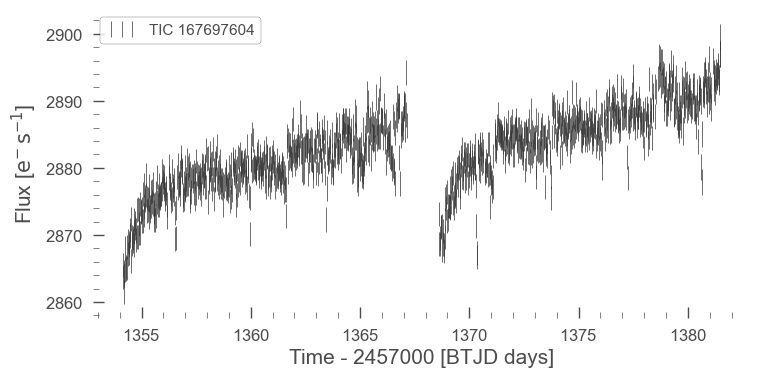

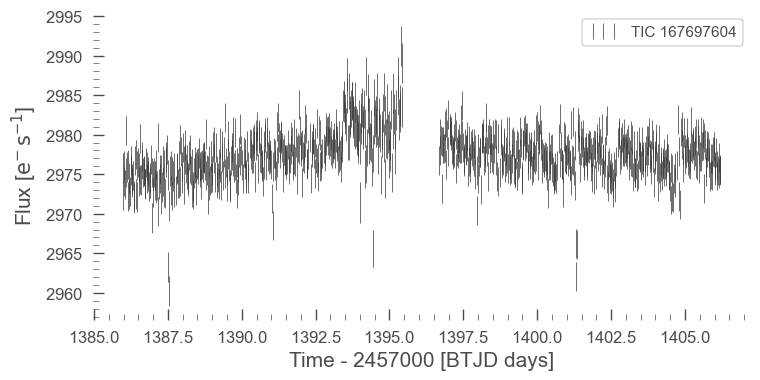

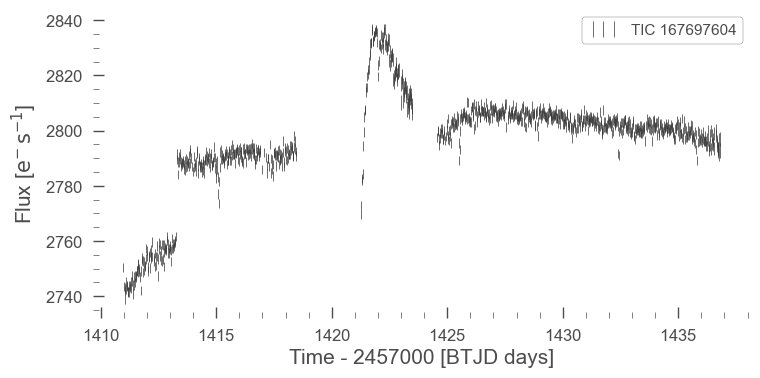

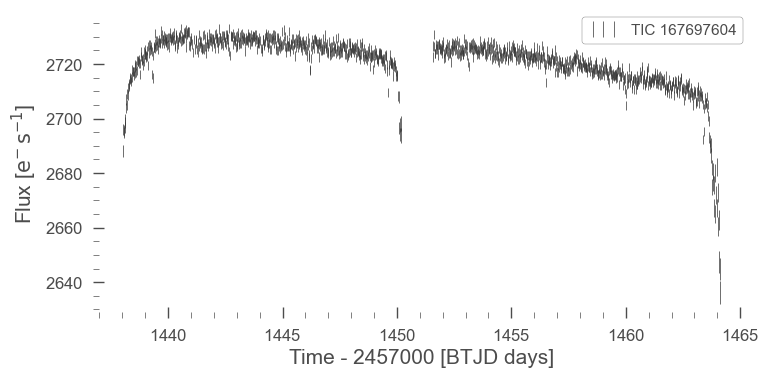

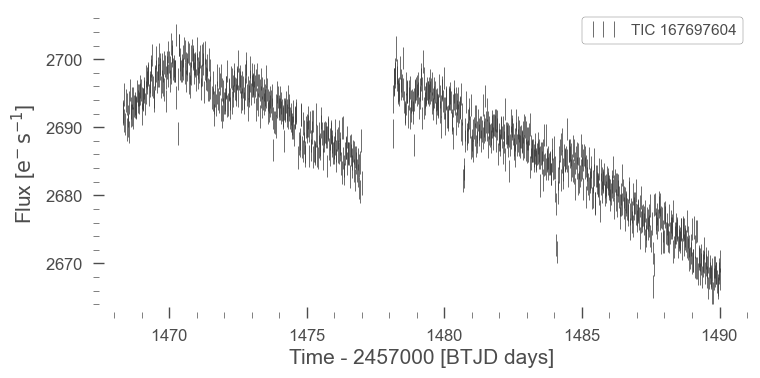

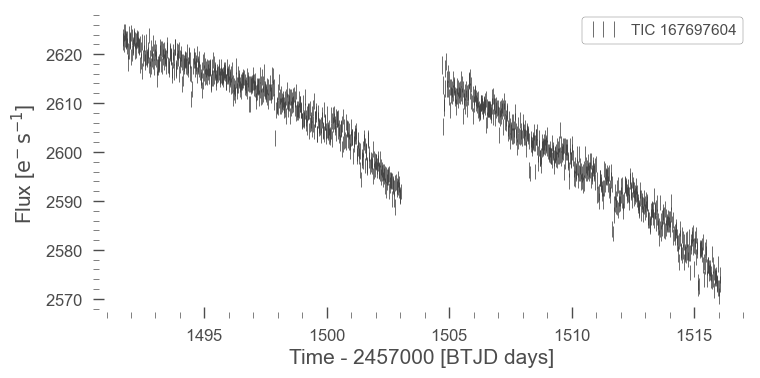

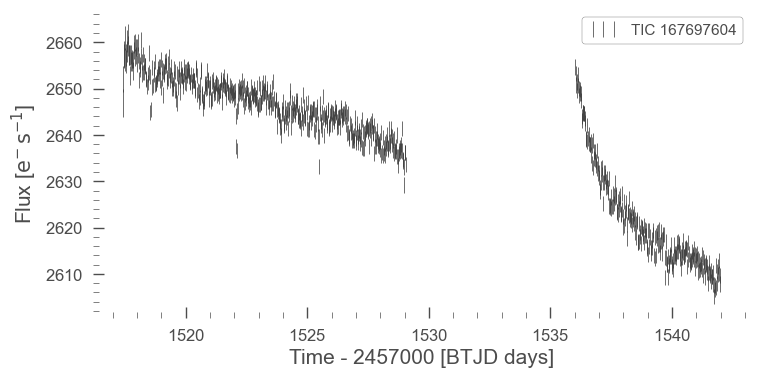

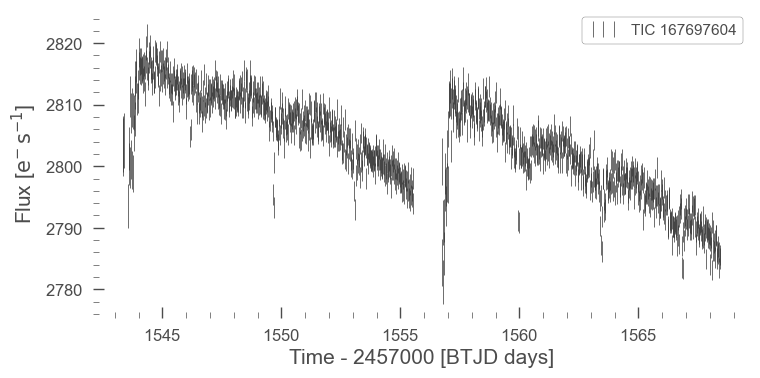

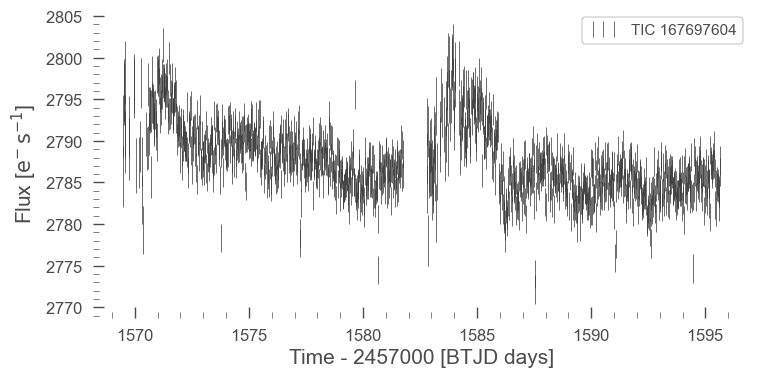

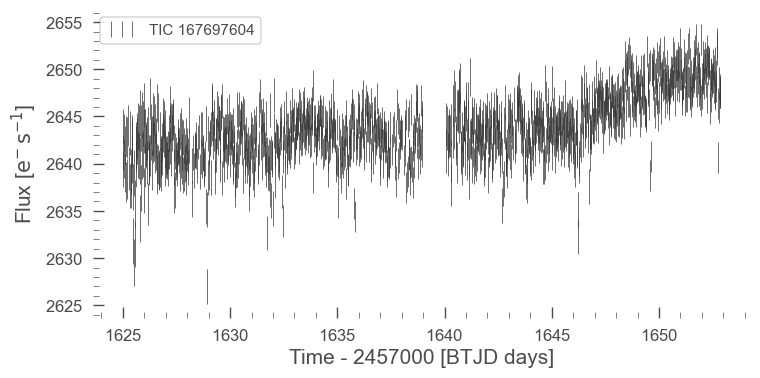

In [7]:
collection = lightkurve.LightCurveCollection(None)
for pixel_file in pixel_files[:]:
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux).all(axis = (1, 2))]
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux_err).all(axis = (1, 2))]

    lc = pixel_file.to_lightcurve(aperture_mask = pixel_file.pipeline_mask)

    lc.errorbar()
    collection.append(lc)

plot.show()

In [8]:
# search_result = lightkurve.search_lightcurve(star_id, mission = 'TESS', cadence = 'long')
# collection = search_result[-1].download_all()
# collection

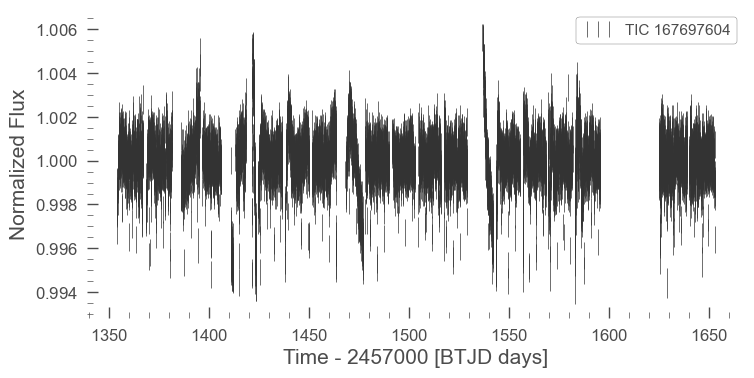

In [32]:
lc = collection[:].stitch().normalize()
lc = lc.flatten(window_length = 501, break_tolerance = 10, niters = 1, sigma = 5).remove_outliers(sigma = 5)
# lc = lc.remove_outliers(sigma = 5)
lc.errorbar()
# plot.gca().set_xlim(1373, 1375)
# plot.gca().set_ylim(0.978, 0.98)
plot.show()

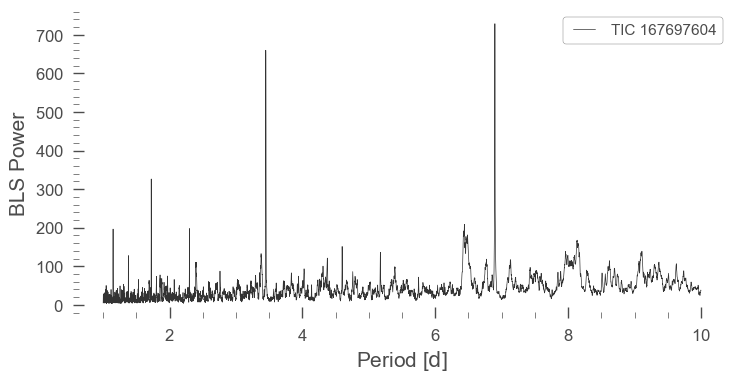

In [34]:
periods = numpy.logspace(0, 1, 10 ** 4, base = 10.0)
periodogram = lc.to_periodogram(method = 'bls', period = periods, frequency_factor = 10 ** 6)
periodogram.plot()
plot.show()

In [35]:
period = periodogram.period_at_max_power
transit_time = periodogram.transit_time_at_max_power
transit_duration = periodogram.duration_at_max_power
period, transit_time, transit_duration

(<Quantity 6.89737547 d>,
 <Time object: scale='tdb' format='btjd' value=1359.9301316421527>,
 <Quantity 0.05 d>)

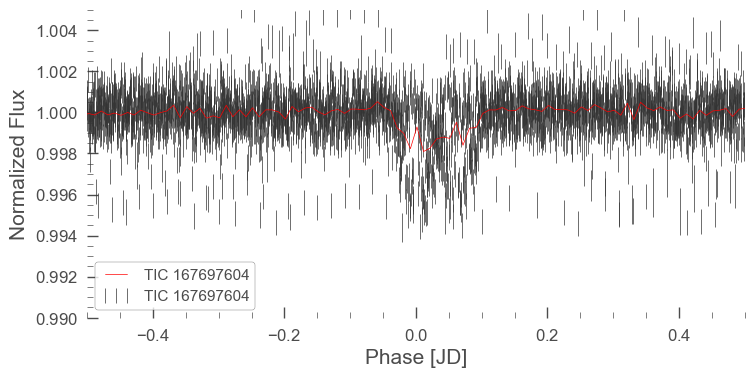

0.0019046650486691519

In [44]:
# transit_time += period / 2 # 2nd eclipse
# period *= 2 # 2nd eclipse
period /= 2 # wrong period
folded_lc = lc.fold(period = period, epoch_time = transit_time)
binned_lc = folded_lc.bin(time_bin_size = 0.01)
ax = folded_lc.errorbar()
binned_lc.plot(ax = ax, c = 'r')
d = 0.5
ax.set_xlim(-d, d)
# ax.set_xlim(-3.4, -2.6)
ax.set_ylim(0.99, 1.005)
plot.show()
transit_depth = 1 - numpy.nanmin(binned_lc.flux.value)
transit_depth

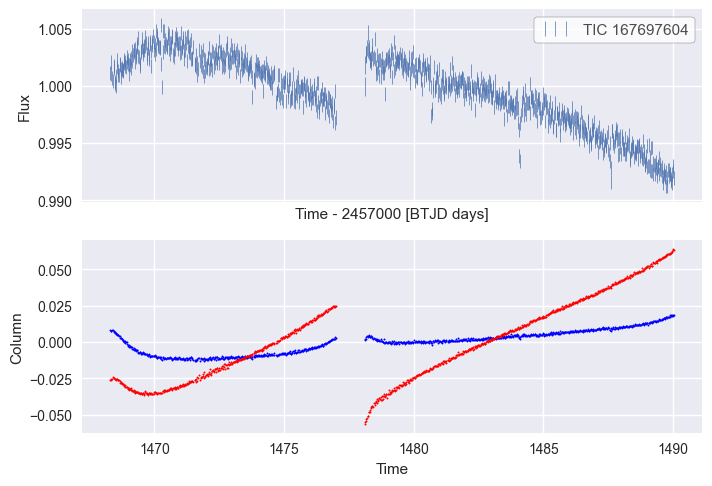

In [ ]:
fig, axes = plot.subplots(2, sharex = True)
pixel_file_range = (0, 1)

c_lc = lightkurve.LightCurveCollection([pixel_file.to_lightcurve() for pixel_file in pixel_files[pixel_file_range[0]:pixel_file_range[1]]]).stitch()
centroids = numpy.concatenate([pixel_file.estimate_centroids() - numpy.nanmean(pixel_file.estimate_centroids(), axis = 1).reshape(-1, 1) for pixel_file in pixel_files[pixel_file_range[0]:pixel_file_range[1]]], axis = 1)

c_lc.errorbar(ax = axes[0])
axes[0].set_ylabel('Flux')

axes[1].scatter(c_lc.time.value, centroids[0], color = 'blue', s = 1)
axes[1].set_ylabel('Row')

axes[1].scatter(c_lc.time.value, centroids[1], color = 'red', s = 1)
axes[1].set_ylabel('Column')
axes[1].set_xlabel('Time')
# plot.xlim(2260, 2262)
# plot.ylim(0, 0.03)
plot.show()

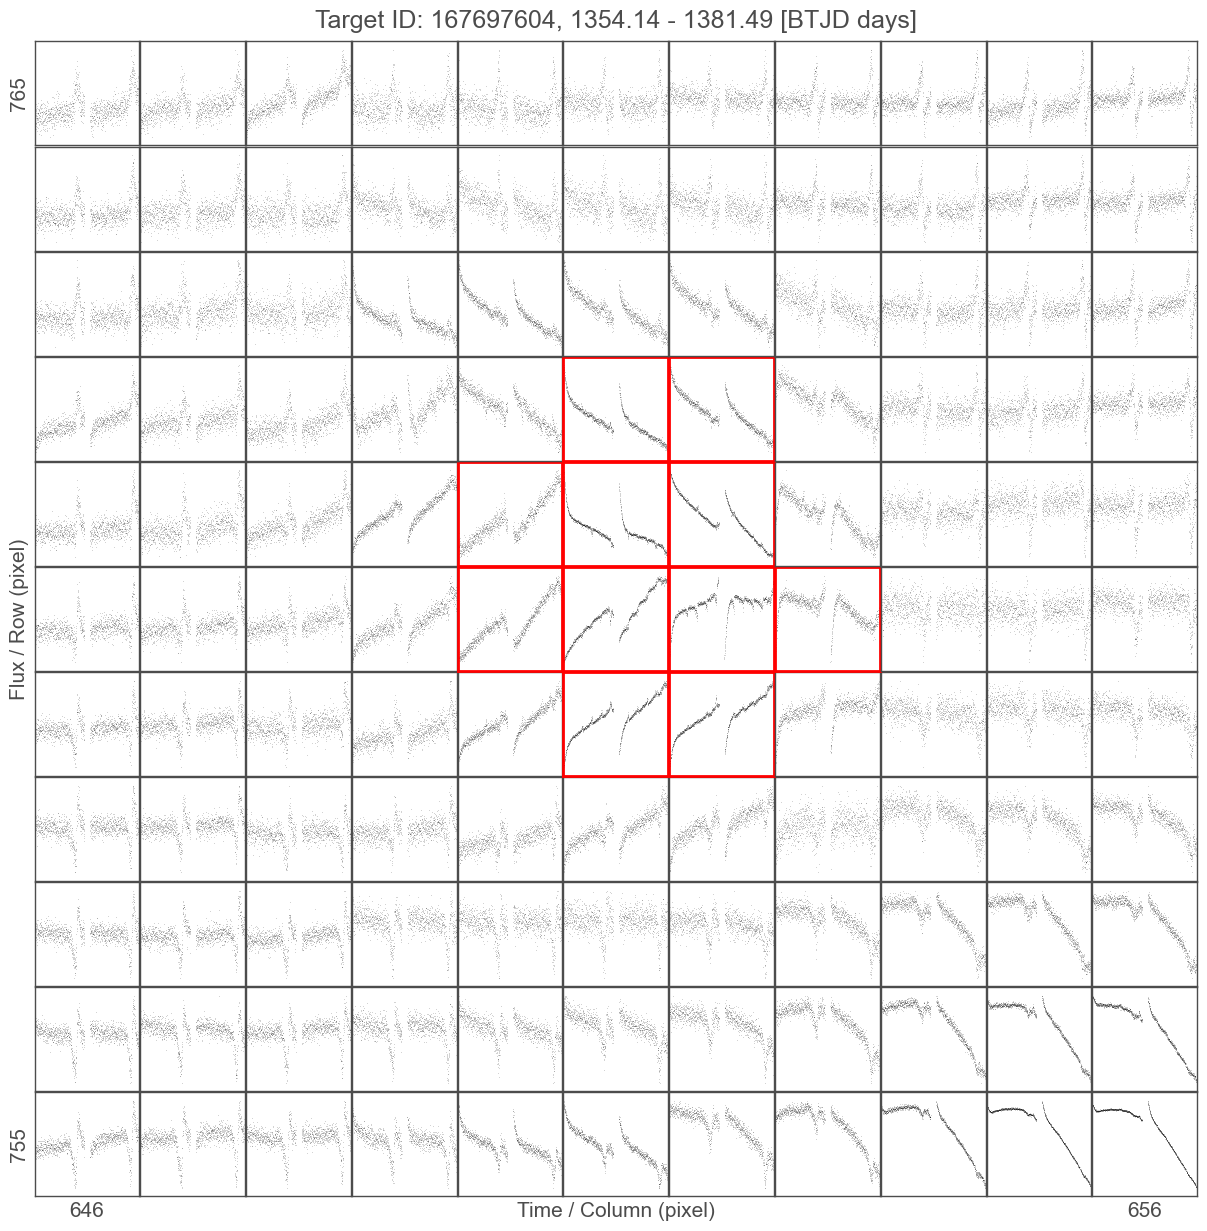

In [14]:
pixel_files[0].plot_pixels(aperture_mask = pixel_files[0].pipeline_mask)
plot.show()